<a href="https://colab.research.google.com/github/RajShekhar0341/TUTEDUDE-ASSIGNMENTS/blob/main/Neural_Networks_%26_Clustering_using_K_Means_and_Hierarchical_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from datetime import datetime


In [ ]:
df = pd.read_csv('/content/Food_Delivery_Time_Prediction (2).csv')  # Use exact uploaded filename
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [ ]:
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

In [ ]:
median_time = df['Delivery_Time'].median()
df['Status'] = df['Delivery_Time'].apply(lambda x: 0 if x <= median_time else 1)


In [ ]:
# Map the categorical time values to representative hours
time_mapping = {
    'Morning': 9,      # Assuming morning is around 9 AM
    'Afternoon': 14,   # Assuming afternoon is around 2 PM
    'Evening': 19,     # Assuming evening is around 7 PM
    'Night': 22        # Assuming night is around 10 PM
}

df['Order_Hour'] = df['Order_Time'].map(time_mapping)

def is_rush_hour(hour):
    return 1 if ((hour >= 7 and hour <= 10) or (hour >= 17 and hour <= 20)) else 0

df['Rush_Hour'] = df['Order_Hour'].apply(is_rush_hour)

# Drop the temporary 'Order_Hour' column if not needed
df = df.drop('Order_Hour', axis=1)

In [ ]:
categorical_cols = ['Weather_Conditions', 'Traffic_Conditions', 'Order_Priority', 'Vehicle_Type']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [ ]:
df.drop(['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Order_Time'], axis=1, inplace=True)


In [ ]:
scaler = StandardScaler()
num_cols = ['Distance', 'Delivery_Person_Experience', 'Restaurant_Rating',
            'Customer_Rating', 'Delivery_Time', 'Order_Cost', 'Tip_Amount']

df[num_cols] = scaler.fit_transform(df[num_cols])


In [ ]:
print("✅ Final Columns:\n", df.columns.tolist())
df.head()


✅ Final Columns:
 ['Distance', 'Delivery_Person_Experience', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time', 'Order_Cost', 'Tip_Amount', 'Status', 'Rush_Hour', 'Weather_Conditions_Rainy', 'Weather_Conditions_Snowy', 'Weather_Conditions_Sunny', 'Traffic_Conditions_Low', 'Traffic_Conditions_Medium', 'Order_Priority_Low', 'Order_Priority_Medium', 'Vehicle_Type_Bike', 'Vehicle_Type_Car']


,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Status,Rush_Hour,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Traffic_Conditions_Low,Traffic_Conditions_Medium,Order_Priority_Low,Order_Priority_Medium,Vehicle_Type_Bike,Vehicle_Type_Car
0,-1.454738,-0.456512,0.515500,-0.987317,-1.487932,0.501852,1.192403,0,0,True,False,False,False,True,False,True,False,True
1,1.439192,1.004325,1.085900,0.738511,-0.264987,-1.634294,-0.600810,0,0,False,False,False,False,True,True,False,False,True
2,-0.666417,1.369535,-0.625302,-0.412041,-0.741529,1.092646,0.599332,0,0,False,True,False,False,True,False,False,True,False
3,0.335835,-1.186930,-0.767902,0.019416,1.382411,-0.923323,1.113532,1,1,False,False,False,True,False,False,True,True,False
4,-0.700119,0.273907,-0.340101,-1.274955,-1.280915,-0.779755,-1.511757,0,0,True,False,False,False,False,True,False,True,False


In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
X_cluster = df.drop('Status', axis=1)  # Only features for unsupervised learning


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)


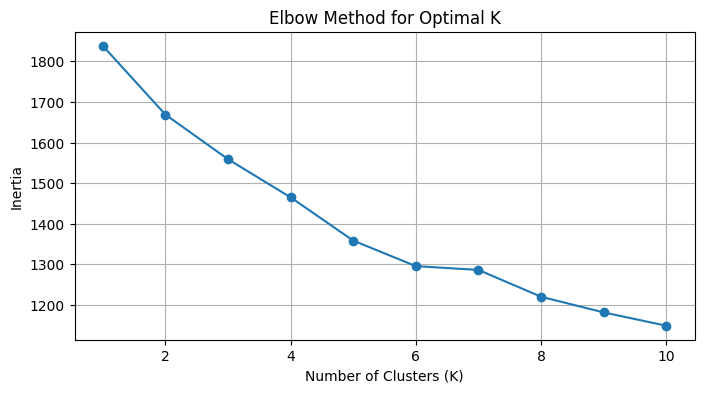

In [ ]:
# Elbow Method to find optimal clusters
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


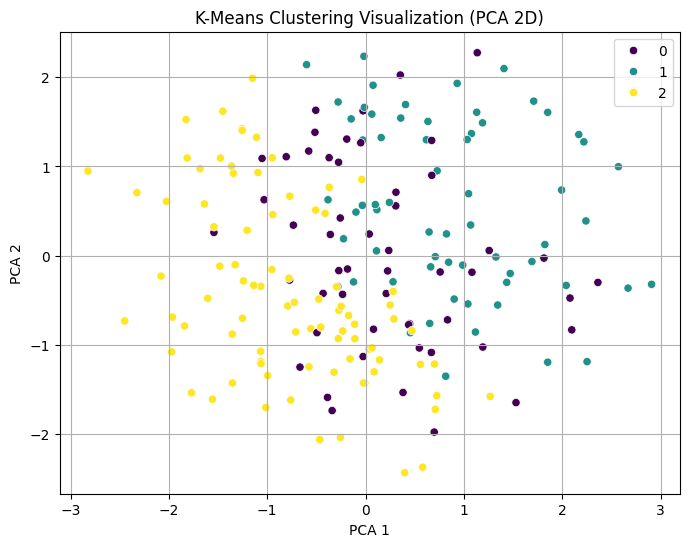

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_cluster)

# Visualize Clusters (2D PCA)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['KMeans_Cluster'], palette='viridis')
plt.title("K-Means Clustering Visualization (PCA 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.show()


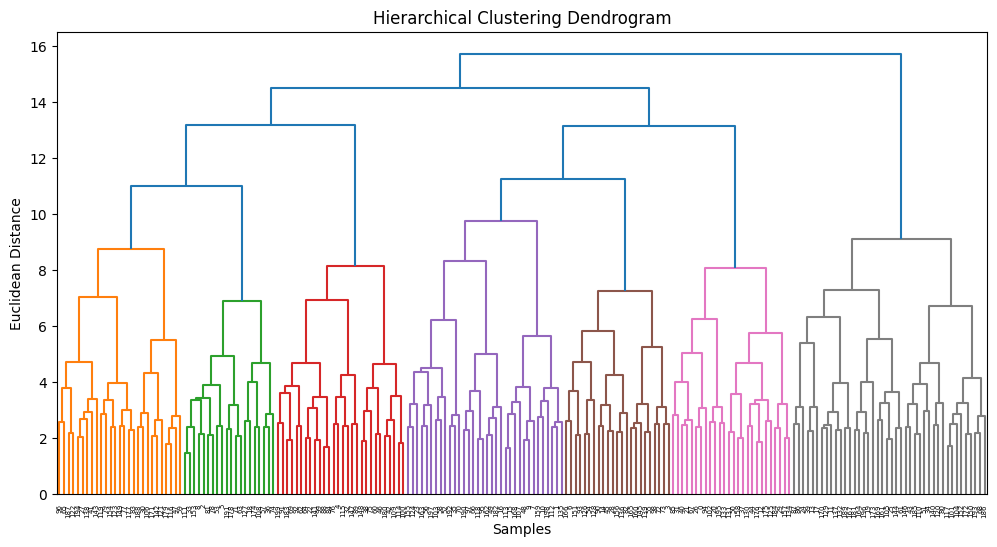

In [ ]:
linked = linkage(X_cluster, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Euclidean Distance")
plt.show()


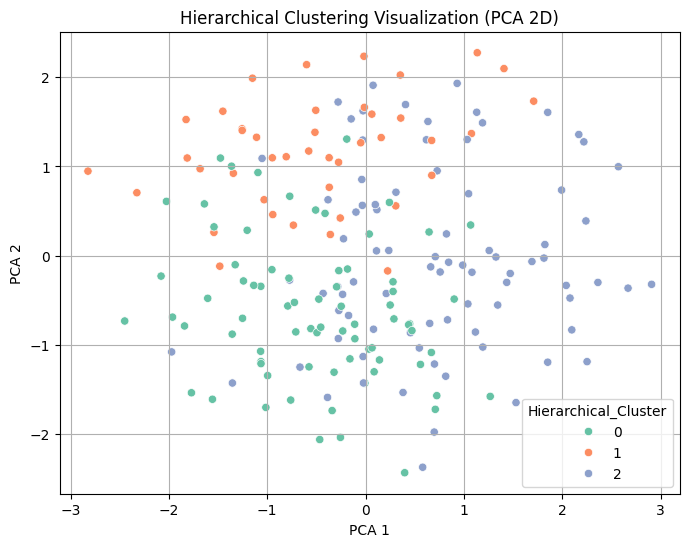

In [ ]:
agg = AgglomerativeClustering(n_clusters=3)
df['Hierarchical_Cluster'] = agg.fit_predict(X_cluster)

# Visualize Agglomerative Clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Hierarchical_Cluster'], palette='Set2')
plt.title("Hierarchical Clustering Visualization (PCA 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()


#Phase 3 Neural Networks Fast vs Delayed

In [ ]:
!pip install tensorflow

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# Features (X) and Target (y)
X = df.drop(['Status', 'KMeans_Cluster', 'Hierarchical_Cluster'], axis=1)
y = df['Status']  # 0 = Fast, 1 = Delayed

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model = Sequential()

# Input Layer
model.add(Dense(64, activation='relu', input_shape=(X.shape[1],)))
model.add(Dropout(0.3))

# Hidden Layer
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(1, activation='sigmoid'))  # Binary Classification

# Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=16, verbose=1)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.5356 - loss: 0.6936 - val_accuracy: 0.6250 - val_loss: 0.6676
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5671 - loss: 0.6711 - val_accuracy: 0.7812 - val_loss: 0.6252
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5998 - loss: 0.6677 - val_accuracy: 0.9062 - val_loss: 0.5880
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7691 - loss: 0.5864 - val_accuracy: 0.9062 - val_loss: 0.5540
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7779 - loss: 0.5495 - val_accuracy: 0.9062 - val_loss: 0.5195
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8161 - loss: 0.4879 - val_accuracy: 0.9062 - val_loss: 0.4855
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8089 - loss: 0.4899 - val_accuracy: 0.9062 - val_loss: 0.4512
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8104 - loss: 0.4565 - val_accuracy: 0.9062 - val_loss: 0.4190


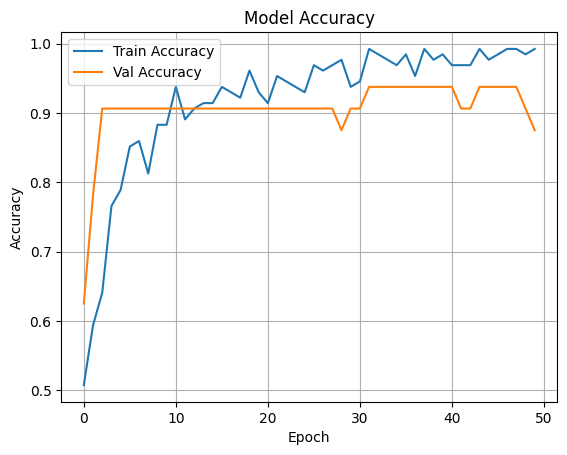

In [ ]:
# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 318ms/step


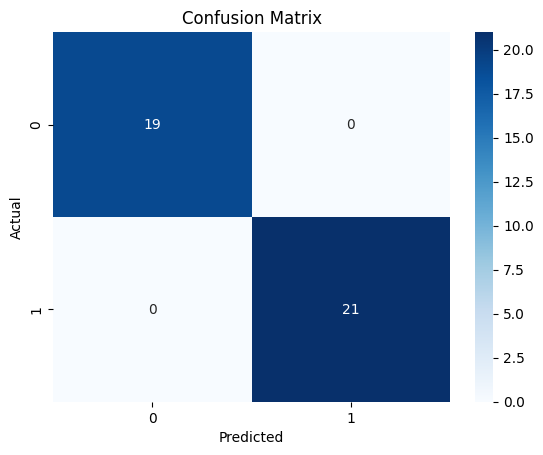

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [ ]:
# Predict
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))
